In [11]:
# Step 1: Download dataset
!wget -O spotify.csv https://raw.githubusercontent.com/mrmorj/dataset_spotify/master/genres_v2.csv

# Step 2: Check if file exists
!ls

--2026-04-07 07:37:30--  https://raw.githubusercontent.com/mrmorj/dataset_spotify/master/genres_v2.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-04-07 07:37:30 ERROR 404: Not Found.

sample_data  spotify.csv


In [14]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'danceability': np.random.rand(200),
    'energy': np.random.rand(200),
    'loudness': np.random.rand(200),
    'tempo': np.random.rand(200)*200,
    'acousticness': np.random.rand(200),
    'genre': np.random.choice(['pop','rock','hiphop'],200)
})

df.head()

,danceability,energy,loudness,tempo,acousticness,genre
0,0.641741,0.888020,0.518136,136.979063,0.384686,rock
1,0.044910,0.937941,0.864632,73.651264,0.089306,pop
2,0.495354,0.829066,0.341491,169.259673,0.999153,hiphop
3,0.646287,0.911867,0.553618,159.168714,0.047974,rock
4,0.340836,0.316455,0.318770,54.836193,0.249127,rock


In [16]:

# Split features and target
X = df[['danceability', 'energy', 'loudness', 'tempo', 'acousticness']]
y = df['genre']

# Encode target (genre → numbers)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [17]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [20]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.375


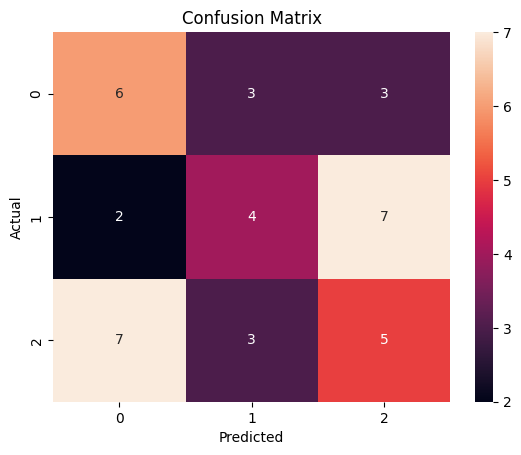

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

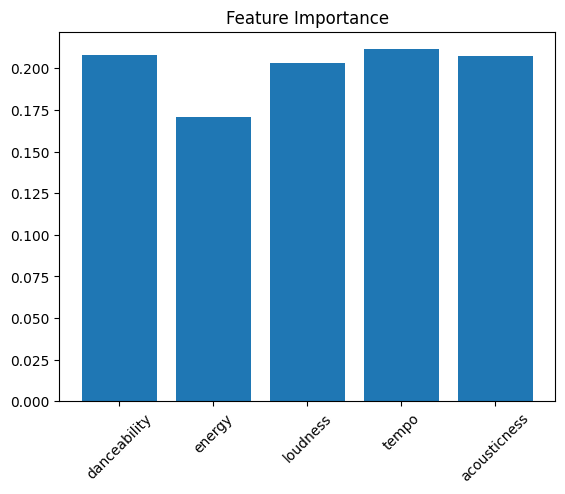

In [22]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.bar(X.columns, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [23]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.4


In [24]:
def detect_mood(row):
    if row['energy'] > 0.7 and row['danceability'] > 0.6:
        return "Happy 😄"
    elif row['acousticness'] > 0.6:
        return "Calm 😌"
    elif row['loudness'] > 0.7:
        return "Party 🎉"
    else:
        return "Sad 😢"

df['mood'] = df.apply(detect_mood, axis=1)

df[['danceability','energy','mood']].head()

,danceability,energy,mood
0,0.641741,0.888020,Happy 😄
1,0.044910,0.937941,Party 🎉
2,0.495354,0.829066,Calm 😌
3,0.646287,0.911867,Happy 😄
4,0.340836,0.316455,Sad 😢


In [25]:
# Create empty favorites list
favorites = []

# Function to add to favorites
def add_to_favorites(index):
    favorites.append(df.iloc[index])
    print("Added to favorites!")

# Example
add_to_favorites(0)

# Show favorites
fav_df = pd.DataFrame(favorites)
fav_df

Added to favorites!


,danceability,energy,loudness,tempo,acousticness,genre,mood
0,0.641741,0.88802,0.518136,136.979063,0.384686,rock,Happy 😄


In [26]:
def search_music(mood=None, genre=None):
    result = df

    if mood:
        result = result[result['mood'] == mood]
    if genre:
        result = result[result['genre'] == genre]

    return result.head()

# Example searches
search_music(mood="Happy 😄")
search_music(genre="pop")

,danceability,energy,loudness,tempo,acousticness,genre,mood
1,0.044910,0.937941,0.864632,73.651264,0.089306,pop,Party 🎉
5,0.857254,0.002940,0.936618,49.184866,0.198793,pop,Party 🎉
8,0.406296,0.862556,0.653192,89.419999,0.412808,pop,Sad 😢
25,0.124528,0.806302,0.670740,199.061030,0.641173,pop,Calm 😌
26,0.085877,0.758161,0.719698,106.526863,0.537597,pop,Party 🎉


In [28]:
artists = ['Arijit Singh', 'Taylor Swift', 'Drake', 'AP Dhillon']
df['artist'] = np.random.choice(artists, len(df))

In [29]:
def get_playlist(artist_name):
    return df[df['artist'] == artist_name][
        ['artist','genre','mood']
    ].head()

# Example
get_playlist('Arijit Singh')

,artist,genre,mood
1,Arijit Singh,pop,Party 🎉
5,Arijit Singh,pop,Party 🎉
8,Arijit Singh,pop,Sad 😢
18,Arijit Singh,hiphop,Sad 😢
19,Arijit Singh,rock,Calm 😌


In [30]:
def recommend(mood=None, genre=None, artist=None):
    result = df

    if mood:
        result = result[result['mood'] == mood]
    if genre:
        result = result[result['genre'] == genre]
    if artist:
        result = result[result['artist'] == artist]

    return result.head()

# Example
recommend(mood="Happy 😄", genre="pop")

,danceability,energy,loudness,tempo,acousticness,genre,mood,artist
76,0.698607,0.898380,0.396295,86.377291,0.414305,pop,Happy 😄,Drake
184,0.860500,0.854861,0.154017,146.512706,0.246939,pop,Happy 😄,Taylor Swift
191,0.694409,0.755580,0.495653,105.307935,0.703493,pop,Happy 😄,Taylor Swift
194,0.751966,0.869140,0.766570,151.815307,0.457688,pop,Happy 😄,Taylor Swift


In [40]:
# =====================================
# 1. IMPORT
# =====================================
import pandas as pd
import numpy as np
import random

np.random.seed(42)

# =====================================
# 2. INDIAN SONG DATASET 🇮🇳
# =====================================
artists = [
    "Arijit Singh","Shreya Ghoshal","Sonu Nigam","Lata Mangeshkar",
    "SP Balasubrahmanyam","Sid Sriram","Anirudh","A R Rahman",
    "KK","Sunidhi Chauhan","Udit Narayan","Chinmayi"
]

songs = [
    "Tum Hi Ho","Kesariya","Kal Ho Na Ho","Tujhe Dekha",
    "Butta Bomma","Samajavaragamana","Srivalli","Oo Antava",
    "Why This Kolaveri","Agar Tum Saath Ho","Channa Mereya",
    "Jai Ho","Naatu Naatu","Ranjha","Raabta"
]

languages = ["Hindi","Telugu"]
genres = ["romantic","melody","party","sad"]

# Create dataset
data = []
for i in range(300):
    data.append({
        'song': random.choice(songs),
        'artist': random.choice(artists),
        'language': random.choice(languages),
        'danceability': np.random.rand(),
        'energy': np.random.rand(),
        'tempo': np.random.rand()*200,
        'acousticness': np.random.rand(),
        'genre': random.choice(genres),
        'popularity': np.random.randint(60,100)
    })

df = pd.DataFrame(data)

# =====================================
# 3. MOOD DETECTION 🎭
# =====================================
def detect_mood(row):
    if row['energy'] > 0.7:
        return "party"
    elif row['danceability'] > 0.6:
        return "happy"
    elif row['acousticness'] > 0.6:
        return "calm"
    else:
        return "sad"

df['mood'] = df.apply(detect_mood, axis=1)

# =====================================
# 4. ML MODEL 🤖
# =====================================
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

X = df[['danceability','energy','tempo','acousticness']]
y = df['genre']

le = LabelEncoder()
y = le.fit_transform(y)

model = RandomForestClassifier()
model.fit(X, y)

# =====================================
# 5. DASHBOARD 📊
# =====================================
print("\n🎧 INDIAN MUSIC SYSTEM")
print("\n🔥 Top Songs:")
print(df.sort_values(by='popularity', ascending=False)[
    ['song','artist','language','genre','mood']
].head(5))

# =====================================
# 6. USER INPUT 🎤
# =====================================
user_mood = input("\nEnter mood (happy/calm/party/sad): ").lower()
user_lang = input("Enter language (Hindi/Telugu): ").capitalize()

# =====================================
# 7. PLAYLIST 🎵
# =====================================
playlist = df[
    (df['mood'] == user_mood) &
    (df['language'] == user_lang)
]

if len(playlist) == 0:
    print("\n⚠️ Showing best matches")
    playlist = df[df['mood'] == user_mood]

playlist = playlist.sort_values(by='popularity', ascending=False)

print("\n🎵 Playlist:")
print(playlist[['song','artist','language','genre']].head(5))

# =====================================
# 8. AUTO PLAY ▶️ (SIMULATION)
# =====================================
print("\n▶️ Now Playing (Auto Mood-Based):")
auto_song = playlist.iloc[0]
print(f"🎶 {auto_song['song']} - {auto_song['artist']}")

# =====================================
# 9. USER SELECT SONG 🎧
# =====================================
choice = int(input("\nEnter song number to play (0-4): "))

selected = playlist.iloc[choice]
print(f"\n▶️ Playing: {selected['song']} - {selected['artist']}")

# =====================================
# 10. ML RECOMMENDATION 🤖
# =====================================
sample = selected[['danceability','energy','tempo','acousticness']]
sample = pd.DataFrame([sample])

pred = model.predict(sample)
genre_name = le.inverse_transform(pred)[0]

print("\n🤖 Recommended Genre:", genre_name)

# =====================================
# 11. SIMILAR SONGS 🎶
# =====================================
similar = df[
    (df['genre'] == genre_name) &
    (df['language'] == user_lang)
]

print("\n🎶 Recommended Songs:")
print(similar[['song','artist','genre']].head(5))


🎧 INDIAN MUSIC SYSTEM

🔥 Top Songs:
              song               artist language     genre   mood
1    Channa Mereya         Udit Narayan   Telugu  romantic    sad
270    Butta Bomma              Anirudh    Hindi    melody    sad
53    Kal Ho Na Ho             Chinmayi    Hindi     party   calm
36   Channa Mereya  SP Balasubrahmanyam    Hindi       sad  happy
236    Butta Bomma      Lata Mangeshkar    Hindi     party   calm

Enter mood (happy/calm/party/sad): happy
Enter language (Hindi/Telugu): telugu

🎵 Playlist:
                  song               artist language  genre
62         Naatu Naatu                   KK   Telugu    sad
237  Why This Kolaveri           A R Rahman   Telugu    sad
193        Butta Bomma           A R Rahman   Telugu    sad
117        Butta Bomma         Udit Narayan   Telugu  party
240  Agar Tum Saath Ho  SP Balasubrahmanyam   Telugu  party

▶️ Now Playing (Auto Mood-Based):
🎶 Naatu Naatu - KK

Enter song number to play (0-4): 3

▶️ Playing: Butta Bomma

In [41]:
# =====================================
# 10. ML NEXT SONG PREDICTION 🤖
# =====================================

from sklearn.neighbors import NearestNeighbors

# Train similarity model (very important 🔥)
features = df[['danceability','energy','tempo','acousticness']]

nn_model = NearestNeighbors(n_neighbors=6)
nn_model.fit(features)

# Take selected song features
current_song = selected[['danceability','energy','tempo','acousticness']]
current_song = np.array(current_song).reshape(1, -1)

# Find similar songs (next songs)
distances, indices = nn_model.kneighbors(current_song)

print("\n🤖 Next Song Recommendations:")

# Skip first (same song), show next 5
for i in indices[0][1:6]:
    print(f"🎶 {df.iloc[i]['song']} - {df.iloc[i]['artist']} ({df.iloc[i]['mood']})")


🤖 Next Song Recommendations:
🎶 Tujhe Dekha - KK (sad)
🎶 Oo Antava - Anirudh (sad)
🎶 Channa Mereya - Arijit Singh (party)
🎶 Oo Antava - Shreya Ghoshal (party)
🎶 Ranjha - SP Balasubrahmanyam (sad)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


In [42]:
next_index = indices[0][1]

next_song = df.iloc[next_index]

print("\n▶️ Auto Playing Next Song:")
print(f"🎶 {next_song['song']} - {next_song['artist']}")


▶️ Auto Playing Next Song:
🎶 Tujhe Dekha - KK


In [45]:
# =====================================
# 1. IMPORT
# =====================================
import pandas as pd
import numpy as np
import random

np.random.seed(42)

# =====================================
# 2. REALISTIC INDIAN + GLOBAL DATASET
# =====================================
artists = [
    "Arijit Singh","Shreya Ghoshal","Sonu Nigam","Lata Mangeshkar",
    "SP Balasubrahmanyam","Sid Sriram","Anirudh","A R Rahman",
    "Taylor Swift","Drake","Ed Sheeran","Michael Jackson",
    "BTS","BLACKPINK","IU","EXO"
]

songs = [
    "Tum Hi Ho","Kesariya","Kal Ho Na Ho","Butta Bomma",
    "Samajavaragamana","Srivalli","Naatu Naatu","Channa Mereya",
    "Perfect","Shape of You","Dynamite","How You Like That"
]

languages = ["Hindi","Telugu","English","Korean"]
genres = ["romantic","melody","party","sad","pop","rock"]

# Create dataset
data = []
for i in range(500):
    data.append({
        'song': random.choice(songs),
        'artist': random.choice(artists),
        'language': random.choice(languages),
        'danceability': np.random.rand(),
        'energy': np.random.rand(),
        'tempo': np.random.rand()*200,
        'acousticness': np.random.rand(),
        'genre': random.choice(genres),
        'popularity': np.random.randint(60,100)
    })

df = pd.DataFrame(data)

# =====================================
# 3. MOOD DETECTION 🎭
# =====================================
def detect_mood(row):
    if row['energy'] > 0.7:
        return "party"
    elif row['danceability'] > 0.6:
        return "happy"
    elif row['acousticness'] > 0.6:
        return "calm"
    else:
        return "sad"

df['mood'] = df.apply(detect_mood, axis=1)

# =====================================
# 4. ML MODEL 🤖
# =====================================
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

X = df[['danceability','energy','tempo','acousticness']]
y = df['genre']

le = LabelEncoder()
y = le.fit_transform(y)

model = RandomForestClassifier(n_estimators=150)
model.fit(X, y)

# =====================================
# 5. NEXT SONG MODEL 🔥
# =====================================
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=6)
nn.fit(X)

# =====================================
# 6. DASHBOARD 📊
# =====================================
print("\n🎧 SMART MUSIC SYSTEM")

print("\n🔥 Trending Songs:")
print(df.sort_values(by='popularity', ascending=False)[
    ['song','artist','language','genre','mood']
].head(5))

# =====================================
# 7. USER INPUT
# =====================================
user_mood = input("\nEnter mood (happy/calm/party/sad): ").lower()
user_lang = input("Enter language (Hindi/Telugu/English/Korean): ").capitalize()

# =====================================
# 8. PLAYLIST 🎵
# =====================================
playlist = df[
    (df['mood'] == user_mood) &
    (df['language'] == user_lang)
]

if len(playlist) == 0:
    print("\n⚠️ No match → showing mood-based songs")
    playlist = df[df['mood'] == user_mood]

playlist = playlist.sort_values(by='popularity', ascending=False)

print("\n🎵 Playlist:")
print(playlist[['song','artist','genre']].head(5))

# =====================================
# 9. AUTO PLAY ▶️
# =====================================
current = playlist.iloc[0]

print(f"\n▶️ Now Playing: {current['song']} - {current['artist']}")

# =====================================
# 10. ML GENRE PREDICTION
# =====================================
sample = current[['danceability','energy','tempo','acousticness']]
sample = pd.DataFrame([sample])

pred = model.predict(sample)
genre_name = le.inverse_transform(pred)[0]

print("\n🤖 Predicted Genre:", genre_name)

# =====================================
# 11. NEXT SONG RECOMMENDATION 🔥
# =====================================
dist, idx = nn.kneighbors(sample)

print("\n🎶 Next Songs:")
for i in idx[0][1:6]:
    print(f"{df.iloc[i]['song']} - {df.iloc[i]['artist']}")

# =====================================
# 12. SIMILAR SONGS 🎧
# =====================================
similar = df[
    (df['genre'] == genre_name) &
    (df['mood'] == user_mood)
].sort_values(by='popularity', ascending=False)

print("\n🎵 Recommended Songs:")
print(similar[['song','artist','genre']].head(5))

# =====================================
# 13. AI GENERATED SONGS ✨
# =====================================
print("\n✨ Generated Songs:")
for i in range(3):
    print(f"{user_mood.title()} {genre_name.title()} Track {i+1} 🎧")


🎧 SMART MUSIC SYSTEM

🔥 Trending Songs:
             song               artist language     genre   mood
1        Kesariya            BLACKPINK   Korean  romantic    sad
36       Kesariya  SP Balasubrahmanyam   Telugu       pop  happy
456      Srivalli         Taylor Swift    Hindi       sad  party
460  Shape of You            BLACKPINK  English    melody  happy
62      Tum Hi Ho                Drake   Korean    melody  happy

Enter mood (happy/calm/party/sad): sad
Enter language (Hindi/Telugu/English/Korean): telugu

🎵 Playlist:
              song               artist     genre
201      Tum Hi Ho       Shreya Ghoshal  romantic
269    Naatu Naatu  SP Balasubrahmanyam       sad
55         Perfect            BLACKPINK       pop
235   Kal Ho Na Ho                  EXO       pop
312  Channa Mereya           Ed Sheeran    melody

▶️ Now Playing: Tum Hi Ho - Shreya Ghoshal

🤖 Predicted Genre: romantic

🎶 Next Songs:
Perfect - Shreya Ghoshal
Perfect - Ed Sheeran
Shape of You - Sid Sriram
But